In [2]:
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm, inv
import numpy as np

In [3]:
# Only iterate over 
def bwgd_subspace(y, A, r, eta = 1, niter = 30):
    d, n = A.shape 
    x = np.zeros((niter, d))  
    x[0] = np.random.randn(d)

    # Covariance matrix transform
    C = A @ A.T / n
    C_sqrt = sqrtm(C)
    C_inv = np.real(inv(C_sqrt))
    A_tilde = C_inv @ A 
    x_tilde = C_sqrt @ x[0]

    # Descent
    for iter in range(1, niter):
        # Subspace
        S,_ = np.linalg.qr(np.random.normal(size = (d, r)))
        P = S @ S.T              # Projection onto S
        Q = (np.eye(d) - P)    # Projection onto S_perp
        
        # Descent
        sum_gradient = A_tilde @ (np.sqrt(y) * (A_tilde.T @ x_tilde) / np.abs(A_tilde.T @ x_tilde))
        x_tilde = (1 - eta) * Q @ x_tilde + (eta / n) * P @ sum_gradient

        x[iter] = C_inv @ x_tilde
        
    return x

In [4]:
# Take minimum error for positive and negative x
def min_error(x_hat, x_star):
    errors = []
    for x in x_hat:
            error_positive = np.linalg.norm(x_star - x)
            error_negative = np.linalg.norm(-1*x_star - x)
            errors.append(min(error_positive, error_negative))
    return errors

# Returns the convergence count for errors for a set of test parameters
def convergence_counts(errors, parameter):
    zero_error = {}
    for i in range(len(errors)):
        zero_error[parameter[i]] = 0
        for error in errors[i]:
            zero_error[parameter[i]] += error[-1] < 1e-11
    return zero_error

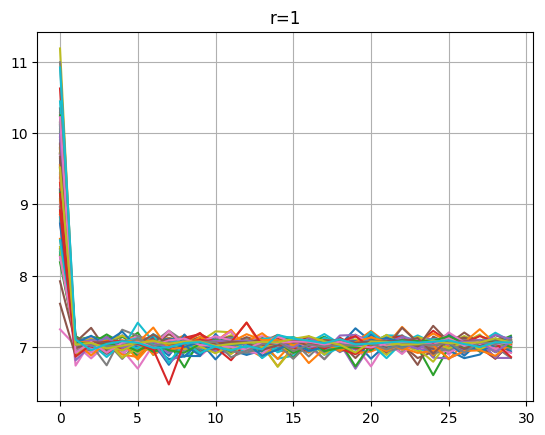

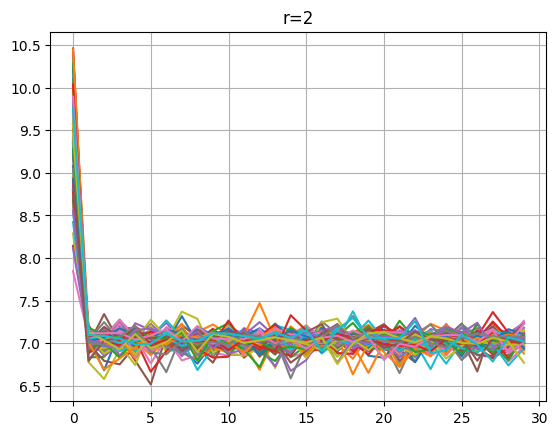

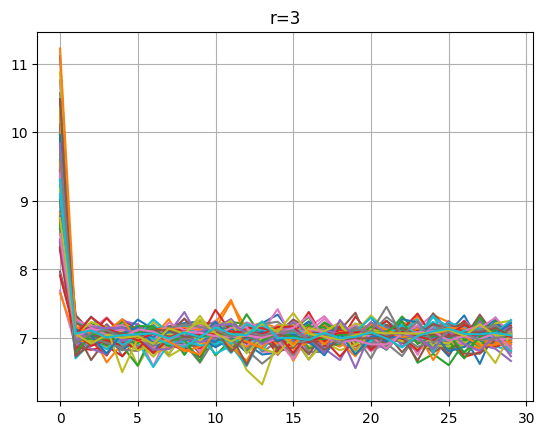

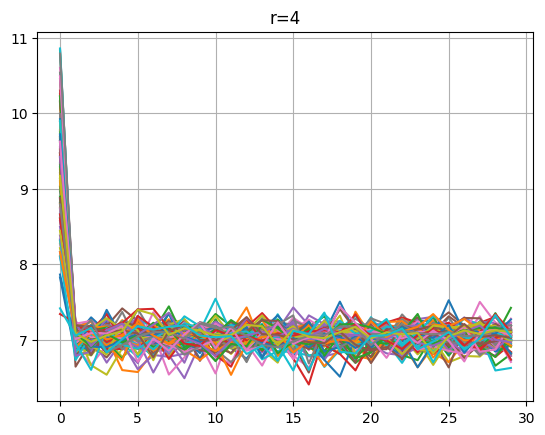

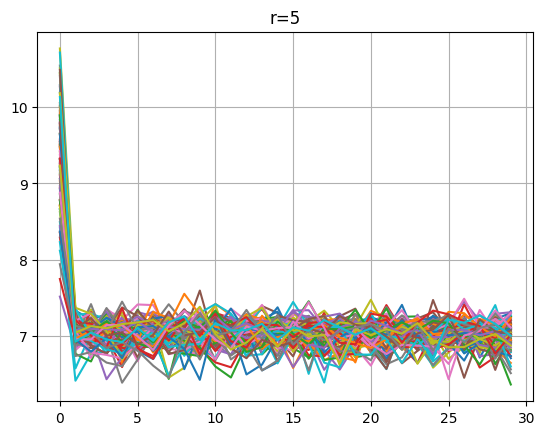

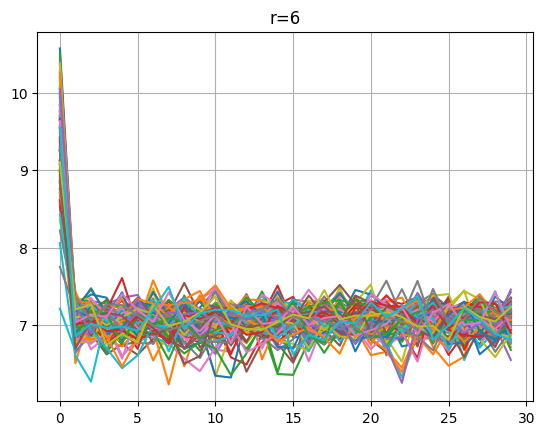

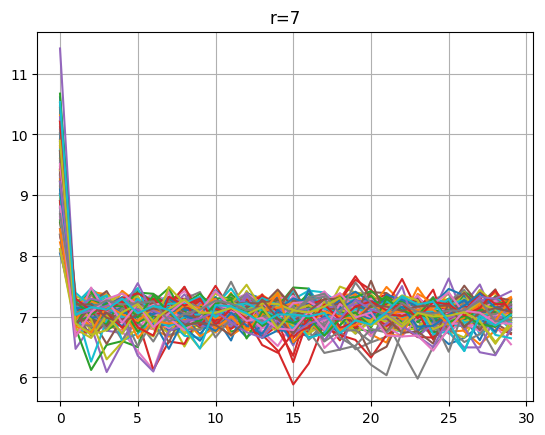

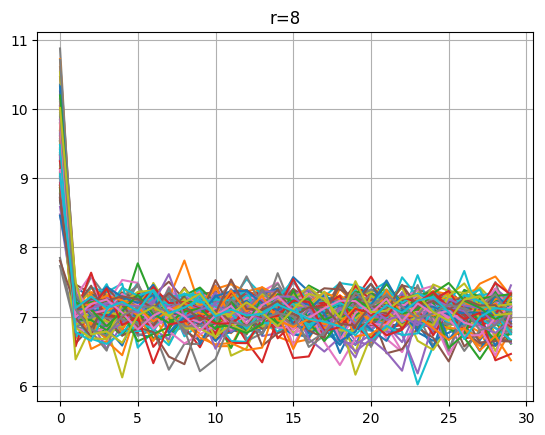

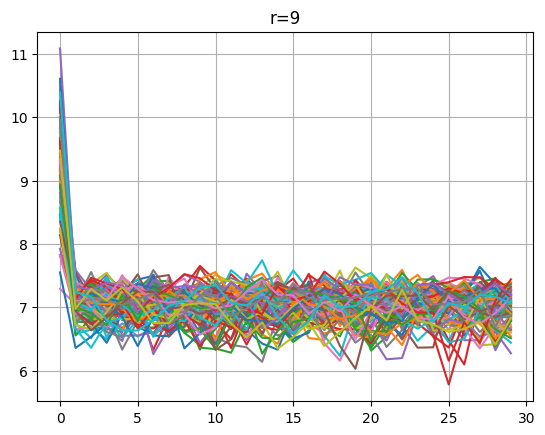

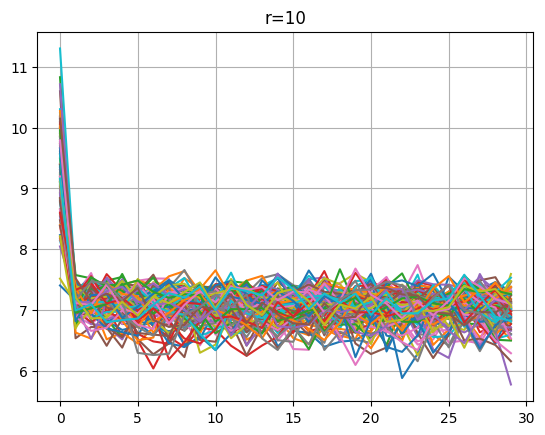

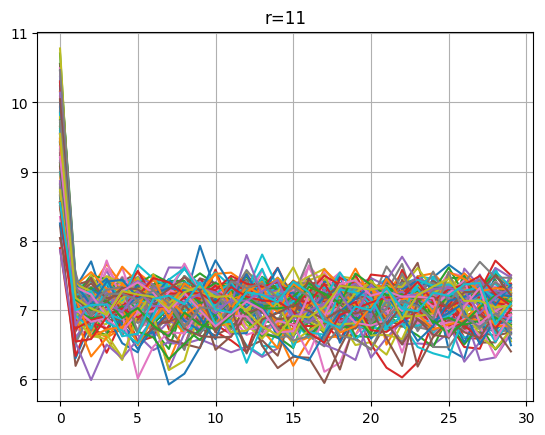

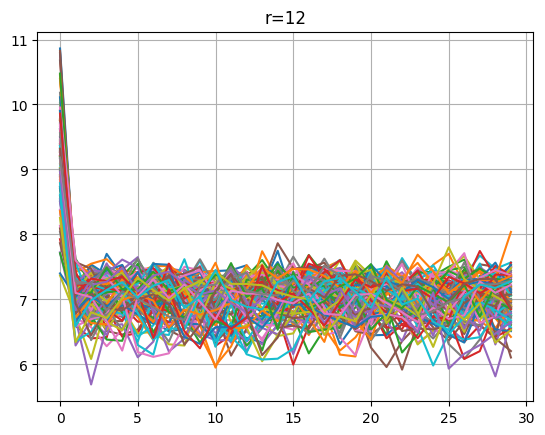

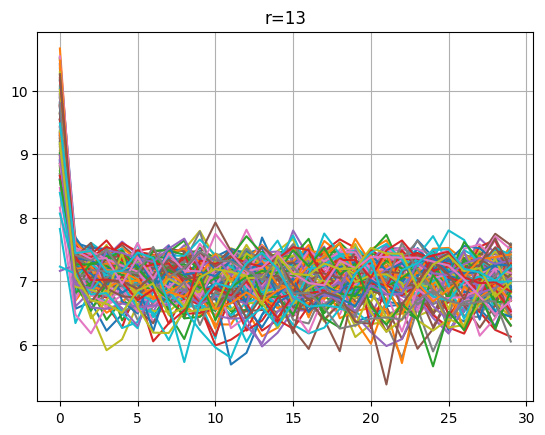

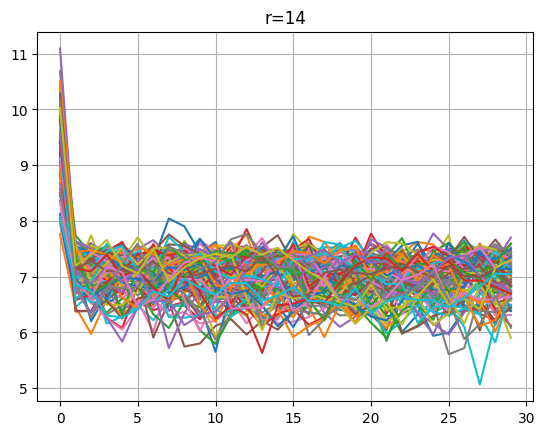

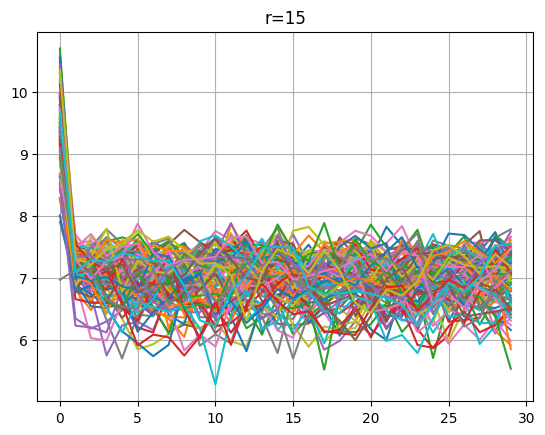

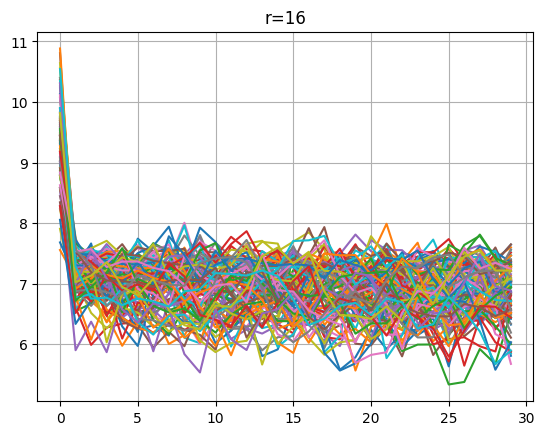

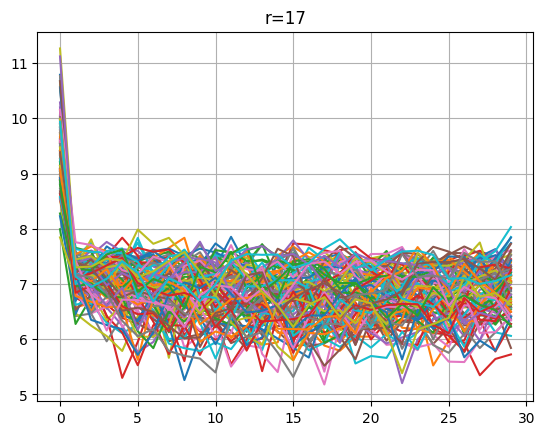

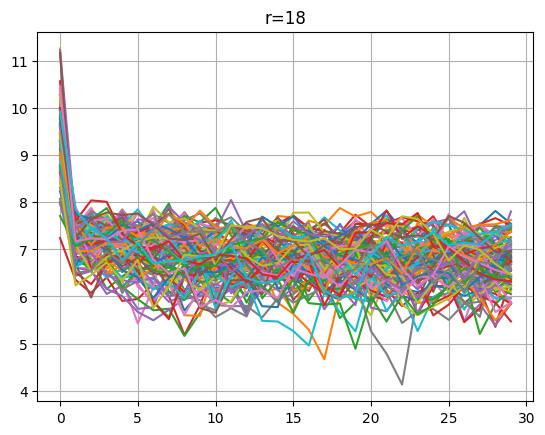

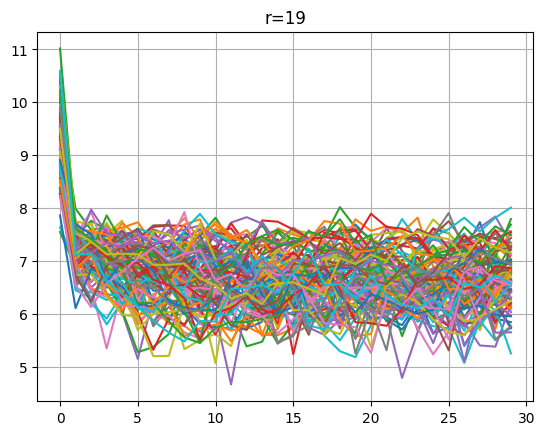

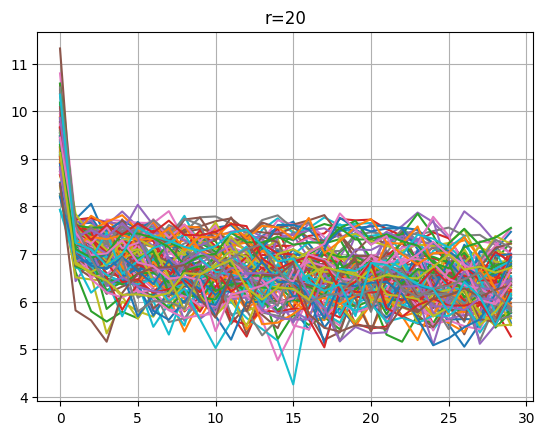

{1: 0,
 2: 0,
 3: 0,
 4: 0,
 5: 0,
 6: 0,
 7: 0,
 8: 0,
 9: 0,
 10: 0,
 11: 0,
 12: 0,
 13: 0,
 14: 0,
 15: 0,
 16: 0,
 17: 0,
 18: 0,
 19: 0,
 20: 0}

In [7]:
n = 1000
d = 50
errors = []
r_vals =  np.arange(1, 21)

for r in r_vals:
    r_error = []
    for j in range(1, 101):  
        # Generate vectors
        x = np.ones(d)
        A = np.random.randn(d, n)
        y = np.square(A.T @ x)
        
        # Run the algorithm
        x_hat = bwgd_subspace(y, A, r)

        error = min_error(x_hat, x)
        r_error.append(error)
        
        # Plot results
        plt.plot(error)

    errors.append(r_error)

    plt.title(f'r={r}')
    plt.grid(True)
    plt.show()

convergence_counts(errors, r_vals)

Use subspace method with thresholding

In [11]:
# Discards the smallest alpha% samples at every iteration
def bwgd_subspace_discard(y, A, r, eta, niter, alpha):
    d, n = A.shape  
    x = np.zeros((niter, d))  
    x[0] = np.random.randn(d)
    threshold = int(alpha * n)

    # Descent
    for iter in range(1, niter):
        # Find indices for smallest |AtX|
        sorted_indices = np.argsort(np.abs(A.T @ x[iter - 1]))
        indices = sorted_indices[threshold:]

        # Discard the selected indices
        A_filtered = A.T[indices].T.copy()
        y_filtered = y[indices].copy()

        # Covariance matrix transform
        C = A_filtered @ A_filtered.T / n
        C_sqrt = sqrtm(C)
        C_inv = np.real(inv(C_sqrt))
        A_tilde = C_inv @ A_filtered 
        x_tilde = C_sqrt @ x[iter - 1]

        # Subspace
        S,_ = np.linalg.qr(np.random.normal(size = (d, r)))
        P = S @ S.T              # Projection onto S
        Q = (np.eye(d) - P)    # Projection onto S_perp

        # Descent
        sum_gradient = A_tilde @ (np.sqrt(y_filtered) * (A_tilde.T @ x_tilde) / np.abs(A_tilde.T @ x_tilde))
        x_tilde = (1 - eta) * Q @ x_tilde + (eta / n) * P @ sum_gradient

        x[iter] = C_inv @ x_tilde
        
    return x

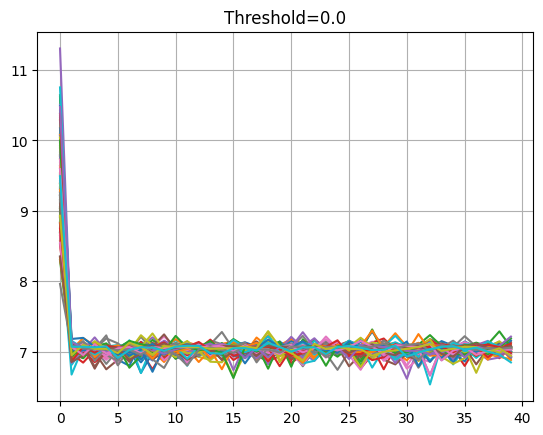

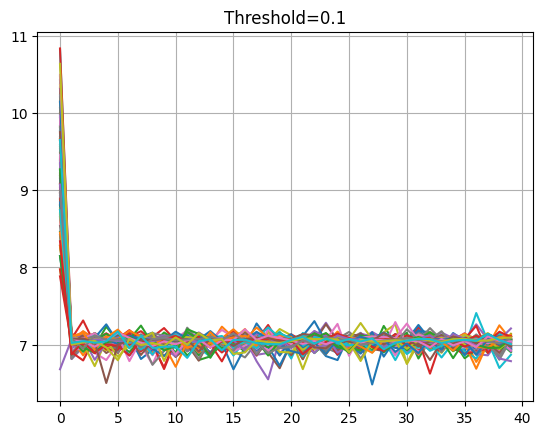

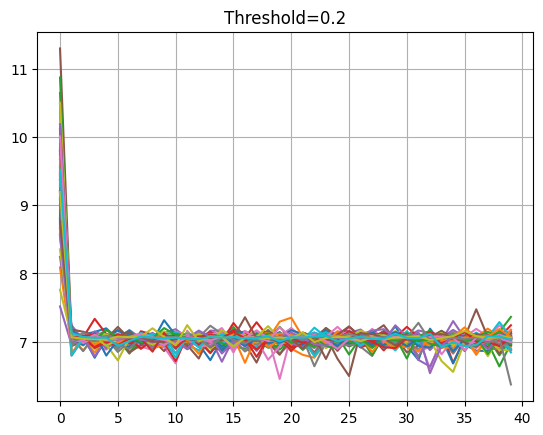

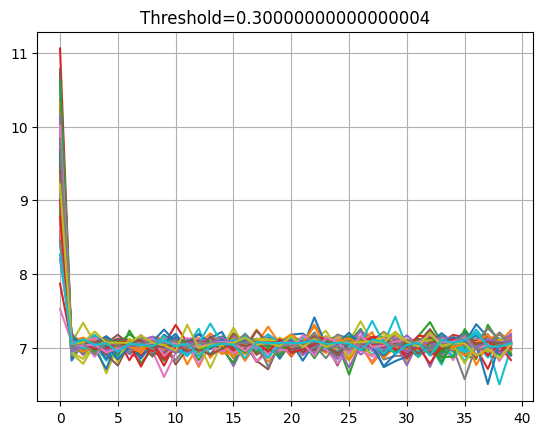

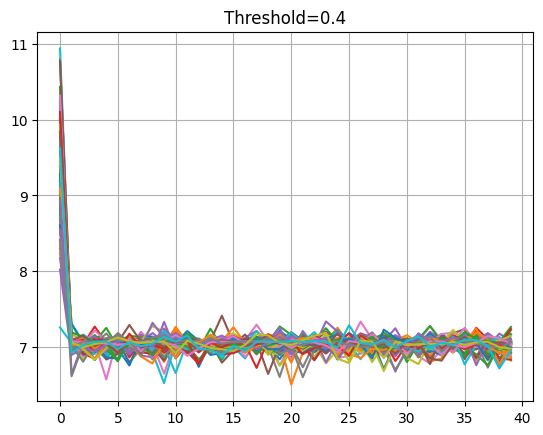

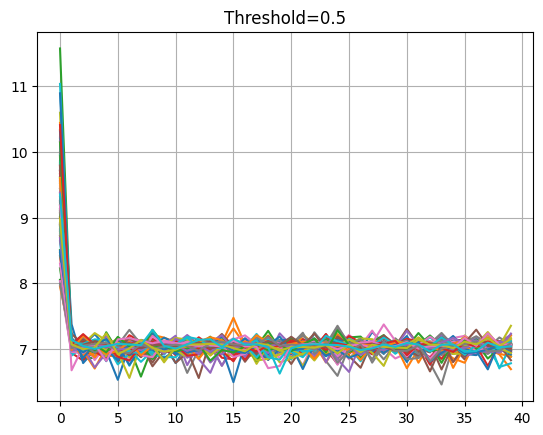

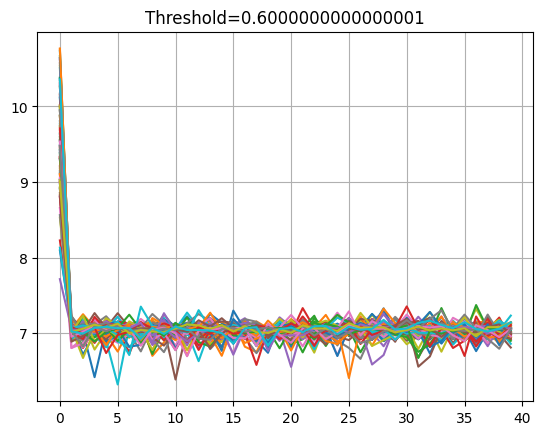

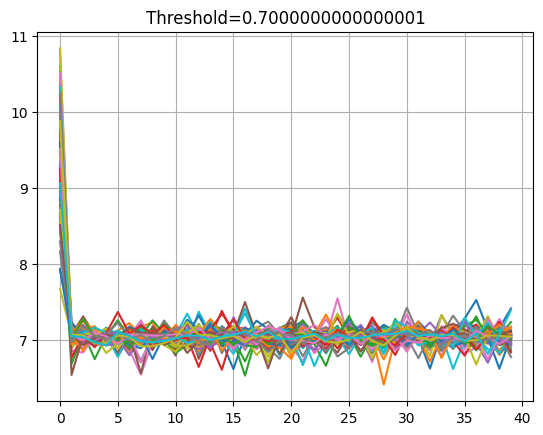

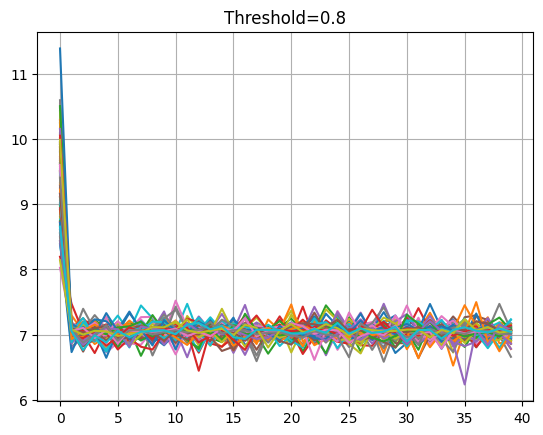

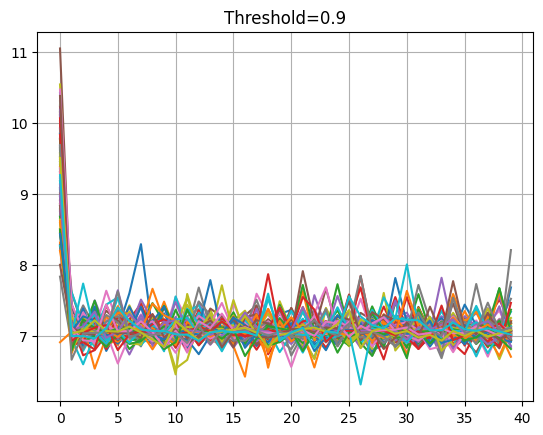

{0.0: 0,
 0.1: 0,
 0.2: 0,
 0.30000000000000004: 0,
 0.4: 0,
 0.5: 0,
 0.6000000000000001: 0,
 0.7000000000000001: 0,
 0.8: 0,
 0.9: 0}

In [13]:
n = 1000
d = 50
errors = []
thresholds =  np.arange(0, 10)*0.1

for threshold in thresholds:
    threshold_error = []
    for j in range(1, 101):  
        # Generate vectors
        x = np.ones(d)
        A = np.random.randn(d, n)
        y = np.square(A.T @ x)
        
        # Run the algorithm
        x_hat = bwgd_subspace_discard(y, A, 1, 1, 40, threshold)

        error = min_error(x_hat, x)
        threshold_error.append(error)
        
        # Plot results
        plt.plot(error)

    errors.append(threshold_error)

    plt.title(f'Threshold={threshold}')
    plt.grid(True)
    plt.show()

convergence_counts(errors, thresholds)

In [265]:
x_hat[-1]

array([-0.01069072,  0.13377138, -0.2294128 ,  0.23094748, -0.45996482,
        0.00444116,  0.33629714, -0.04413838, -0.19086812, -0.51799484,
       -0.10087147, -0.30229768, -0.57049353, -0.12720301, -0.5117937 ,
        0.0051802 , -0.50391881,  0.1119793 , -0.6147448 , -0.37660565,
        0.01789097,  0.18518242,  0.12153146,  0.22676646,  0.19920735,
       -0.01027223,  0.01209171, -0.10592506, -0.18180216,  0.53913036,
       -0.27725827,  0.33698961,  0.39760774,  0.15105503,  0.59087676,
        0.60773637,  0.2369678 ,  0.19084472, -0.53760927, -0.4445825 ,
        0.58160848, -0.18698365,  0.09247994,  0.58724148,  0.26203674,
        0.76339974, -0.17662386, -0.13502763,  0.94554016,  0.03932965])